In [1]:
# import standard python libraries
import matplotlib as mpl
%matplotlib inline
mpl.rcParams['figure.dpi'] = 96
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os, subprocess
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# import libraries for biological data analysis
from coolpuppy import coolpup
from coolpuppy.lib import numutils
from coolpuppy.lib.puputils import divide_pups
from coolpuppy import plotpup
import cooler
import bioframe
import cooltools
from cooltools import expected_cis, expected_trans
from cooltools.lib import plotting

%cd /home/varshini/uc_analyses/
import utils, matchmaker_functions
%cd /home/varshini/LoopCall_Analysis_Scripts

# plot formatting
plt.rcParams["font.family"] = "Arial"

plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True

plt.rcParams['axes.grid'] = True
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams.update({'font.size': 18})


/home/varshini/uc_analyses
/home/varshini/LoopCall_Analysis_Scripts


In [2]:
datapath = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/track_defs/erythroid_tracks'
subdir = 'classifications'

os.listdir(os.path.join(datapath, subdir))

['fosl1_only_eryth.bed',
 'P2_CTCF_10kb_boundaries_100kbw.bed',
 'erythroid_tf_acrs_all_notpromoternotctcf.bed',
 'promoternotctcf_eACRs.bed',
 'P1_CTCF_10kb_boundaries_100kbw.bed',
 'tf_acrs_sorted_promoternotctcf.bed',
 'promoternotctcf_accessible.bed',
 'erythroid_tf_acrs_all_promoternotctcf.bed',
 'tf_acrs_sorted_ctcf.bed',
 'nfe2_only_tf.bed',
 'gfi1b_only_eryth.bed',
 'P3_CTCF_10kb_boundaries_100kbw.bed',
 'tf_acrs_sorted_notpromoter.bed',
 'erythroid_tf_acrs_all_notpromoter.bed',
 'gfi1b_only_tf.bed',
 'fosl1_only_tf.bed',
 'erythroid_tf_acrs_all_ctcf.bed',
 'erythroid_tf_acrs_all_enhancernotpromoter.bed',
 'erythroid_tf_acrs_all_enhancernotpromoternotctcf.bed',
 'tf_acrs_sorted_notpromoternotctcf.bed',
 'erythroid_tf_acrs_all_enhancer.bed',
 'CTCF_10kb_boundaries.bed',
 'CTCF_10kb_boundaries_100kbw.bed',
 'tf_acrs_sorted_enhancernotpromoter.bed',
 'tf_acrs_sorted_enhancer.bed',
 'erythroid_tf_acrs_all_promoter.bed',
 'tf_acrs_sorted_promoter.bed',
 'nfe2_only_eryth.bed',
 'tf_a

In [3]:
bedfiles = {}
for f in os.listdir(os.path.join(datapath, subdir)):
    trunc = f.split('.')[0]
    print(trunc)
    if 'tf_acrs' in f:
        bedfiles[trunc] = matchmaker_functions.read_bedsites_flex(os.path.join(datapath, subdir, f), sort='last')
    else:
        bedfiles[trunc] = matchmaker_functions.read_bedsites_flex(os.path.join(datapath, subdir, f))

fosl1_only_eryth
P2_CTCF_10kb_boundaries_100kbw
erythroid_tf_acrs_all_notpromoternotctcf
promoternotctcf_eACRs
P1_CTCF_10kb_boundaries_100kbw
tf_acrs_sorted_promoternotctcf
promoternotctcf_accessible
erythroid_tf_acrs_all_promoternotctcf
tf_acrs_sorted_ctcf
nfe2_only_tf
gfi1b_only_eryth
P3_CTCF_10kb_boundaries_100kbw
tf_acrs_sorted_notpromoter
erythroid_tf_acrs_all_notpromoter
gfi1b_only_tf
fosl1_only_tf
erythroid_tf_acrs_all_ctcf
erythroid_tf_acrs_all_enhancernotpromoter
erythroid_tf_acrs_all_enhancernotpromoternotctcf
tf_acrs_sorted_notpromoternotctcf
erythroid_tf_acrs_all_enhancer
CTCF_10kb_boundaries
CTCF_10kb_boundaries_100kbw
tf_acrs_sorted_enhancernotpromoter
tf_acrs_sorted_enhancer
erythroid_tf_acrs_all_promoter
tf_acrs_sorted_promoter
nfe2_only_eryth
tf_acrs_sorted_enhancernotpromoternotctcf


In [4]:
print(bedfiles.keys())

dict_keys(['fosl1_only_eryth', 'P2_CTCF_10kb_boundaries_100kbw', 'erythroid_tf_acrs_all_notpromoternotctcf', 'promoternotctcf_eACRs', 'P1_CTCF_10kb_boundaries_100kbw', 'tf_acrs_sorted_promoternotctcf', 'promoternotctcf_accessible', 'erythroid_tf_acrs_all_promoternotctcf', 'tf_acrs_sorted_ctcf', 'nfe2_only_tf', 'gfi1b_only_eryth', 'P3_CTCF_10kb_boundaries_100kbw', 'tf_acrs_sorted_notpromoter', 'erythroid_tf_acrs_all_notpromoter', 'gfi1b_only_tf', 'fosl1_only_tf', 'erythroid_tf_acrs_all_ctcf', 'erythroid_tf_acrs_all_enhancernotpromoter', 'erythroid_tf_acrs_all_enhancernotpromoternotctcf', 'tf_acrs_sorted_notpromoternotctcf', 'erythroid_tf_acrs_all_enhancer', 'CTCF_10kb_boundaries', 'CTCF_10kb_boundaries_100kbw', 'tf_acrs_sorted_enhancernotpromoter', 'tf_acrs_sorted_enhancer', 'erythroid_tf_acrs_all_promoter', 'tf_acrs_sorted_promoter', 'nfe2_only_eryth', 'tf_acrs_sorted_enhancernotpromoternotctcf'])


In [5]:
# load coolers, expected values, hg38 arms 
phases= ['Phase1_','Phase2_dedup', 'Phase3_dedup']
expdir = os.path.join('/mnt/md0/varshini/Analysis/Blood', 'microc_expected')
phase_clr_names = [f'/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_{p}merged.250.mcool::resolutions/5000' for p in phases]

#[cooler.fileops.list_coolers(c) for c in phase_clr_names]
phase_clrs = [cooler.Cooler(c) for c in phase_clr_names]
exps = [os.path.join(expdir, f"P_s_{phase}_5000bp_hg38arms.tsv") for phase in phases]

In [6]:
hg38_arms = utils.get_hg38_arms()

In [7]:
control_track = pd.read_csv('/mnt/md0/varshini/Analysis/Blood/Tracks_Intersection_Analysis/track_classifications/enhancernotpromoternotctcfnottf.bed', sep='\t', 
                            names=['chrom','start','end'])
control_track_2 = pd.read_csv('/mnt/md0/varshini/Analysis/Blood/complete_analyses/track_defs/track_classifications/enhancernotpromoternotctcf.bed', sep='\t',
                             names=['chrom','start','end'])


In [8]:
VMAX_GLOBAL = 2**0.5

In [9]:
outdir = os.path.join('/mnt/md0/varshini/Analysis/Blood', 'figs_v2/fig2')
if not os.path.exists(outdir):
    os.mkdir(outdir)

INFO:coolpuppy:('chr8_p', 'chr8_p'): 75
INFO:coolpuppy:('chr5_p', 'chr5_p'): 48
INFO:coolpuppy:('chr4_p', 'chr4_p'): 47
INFO:coolpuppy:('chr7_p', 'chr7_p'): 88
INFO:coolpuppy:('chr6_p', 'chr6_p'): 190
INFO:coolpuppy:('chr2_p', 'chr2_p'): 174
INFO:coolpuppy:('chr3_p', 'chr3_p'): 124
INFO:coolpuppy:('chr8_q', 'chr8_q'): 130
INFO:coolpuppy:('chr9_p', 'chr9_p'): 58
INFO:coolpuppy:('chr7_q', 'chr7_q'): 154
INFO:coolpuppy:('chr1_p', 'chr1_p'): 310
INFO:coolpuppy:('chr6_q', 'chr6_q'): 141
INFO:coolpuppy:('chr4_q', 'chr4_q'): 163
INFO:coolpuppy:('chr5_q', 'chr5_q'): 209
INFO:coolpuppy:('chr9_q', 'chr9_q'): 168
INFO:coolpuppy:('chr10_p', 'chr10_p'): 79
INFO:coolpuppy:('chr12_p', 'chr12_p'): 76
INFO:coolpuppy:('chr11_p', 'chr11_p'): 90
INFO:coolpuppy:('chr3_q', 'chr3_q'): 184
INFO:coolpuppy:('chr2_q', 'chr2_q'): 208
INFO:coolpuppy:('chr16_p', 'chr16_p'): 85
INFO:coolpuppy:('chr13_q', 'chr13_q'): 112
INFO:coolpuppy:('chr17_p', 'chr17_p'): 61
INFO:coolpuppy:('chr14_q', 'chr14_q'): 157
INFO:coolpup

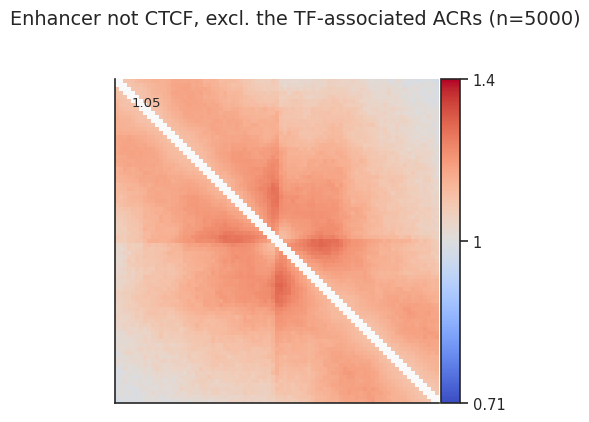

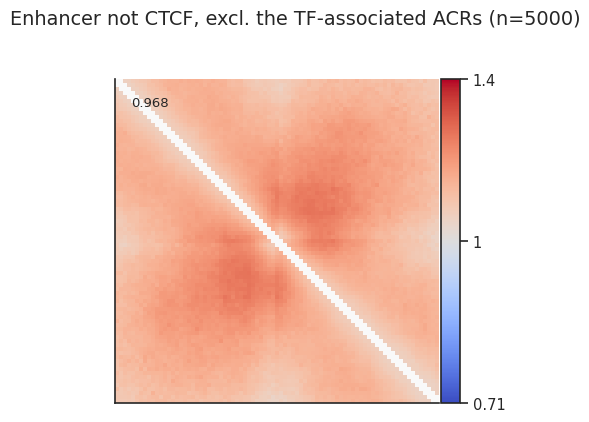

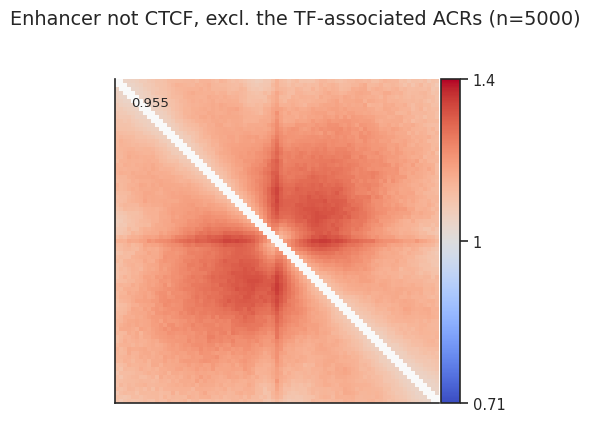

In [37]:
for p in [0, 1, 2]:
    clr = phase_clrs[p]
    exp0 =  pd.read_csv(exps[p], sep='\t')
    pup_control_excl = coolpup.pileup(clr, control_track, features_format='bed', local=True, view_df=hg38_arms,
                                flank=200_000, expected_df = exp0, min_diag=0, nproc=8, subset=5000)
    fg = plotpup.plot(pup_control_excl,
                     score=True, cmap='coolwarm', scale='log', sym=True,
                     height=5, vmax=VMAX_GLOBAL)
    fg.fig.suptitle("Enhancer not CTCF, excl. the TF-associated ACRs (n=5000)")
    fg.savefig(os.path.join(datapath, outdir, f"enot_notf_phase{p+1}.svg"))

INFO:coolpuppy:('chr5_p', 'chr5_p'): 40
INFO:coolpuppy:('chr4_p', 'chr4_p'): 68
INFO:coolpuppy:('chr8_p', 'chr8_p'): 65
INFO:coolpuppy:('chr6_p', 'chr6_p'): 173
INFO:coolpuppy:('chr7_p', 'chr7_p'): 92
INFO:coolpuppy:('chr3_p', 'chr3_p'): 153
INFO:coolpuppy:('chr2_p', 'chr2_p'): 199
INFO:coolpuppy:('chr8_q', 'chr8_q'): 141
INFO:coolpuppy:('chr7_q', 'chr7_q'): 131
INFO:coolpuppy:('chr1_p', 'chr1_p'): 283
INFO:coolpuppy:('chr6_q', 'chr6_q'): 155
INFO:coolpuppy:('chr5_q', 'chr5_q'): 212
INFO:coolpuppy:('chr9_p', 'chr9_p'): 69
INFO:coolpuppy:('chr10_p', 'chr10_p'): 82
INFO:coolpuppy:('chr3_q', 'chr3_q'): 176
INFO:coolpuppy:('chr12_p', 'chr12_p'): 73
INFO:coolpuppy:('chr4_q', 'chr4_q'): 187
INFO:coolpuppy:('chr11_p', 'chr11_p'): 87
INFO:coolpuppy:('chr9_q', 'chr9_q'): 155
INFO:coolpuppy:('chr13_q', 'chr13_q'): 142
INFO:coolpuppy:('chr10_q', 'chr10_q'): 156
INFO:coolpuppy:('chr14_q', 'chr14_q'): 162
INFO:coolpuppy:('chr17_p', 'chr17_p'): 56
INFO:coolpuppy:('chr16_p', 'chr16_p'): 60
INFO:coolp

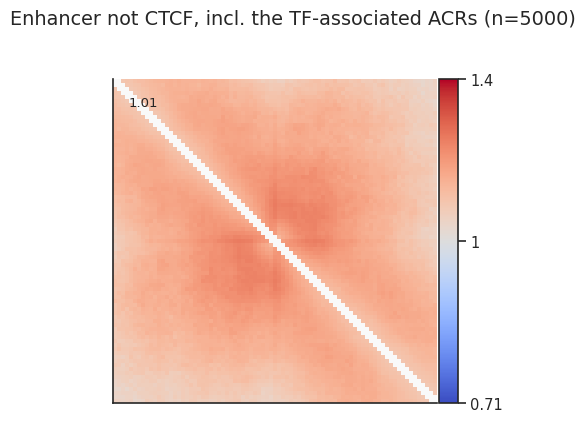

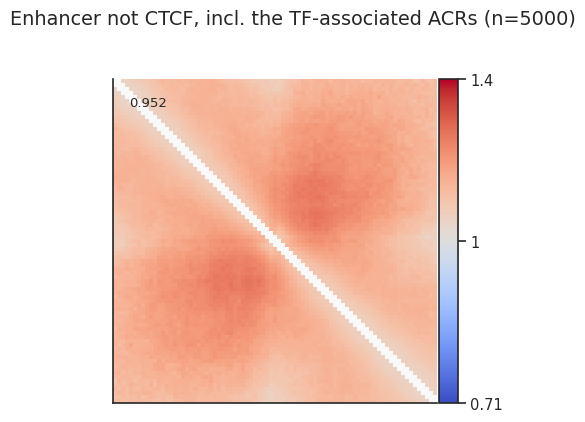

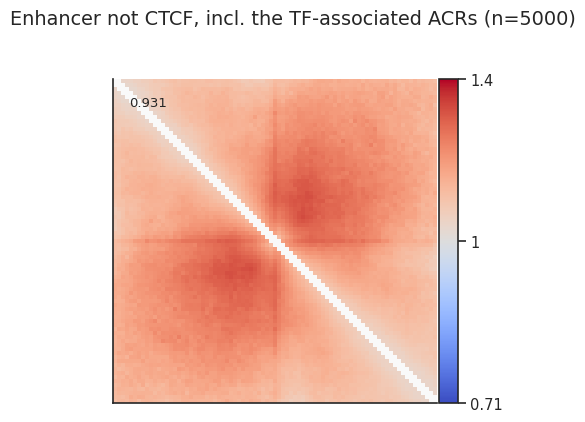

In [38]:
for p in [0, 1, 2]:
    clr = phase_clrs[p]
    exp0 =  pd.read_csv(exps[p], sep='\t')
    pup_control_incl = coolpup.pileup(clr, control_track_2, features_format='bed', local=True, view_df=hg38_arms,
                                flank=200_000, expected_df = exp0, min_diag=0, nproc=8, subset=5000, )
    fg = plotpup.plot(pup_control_incl,
                     score=True, cmap='coolwarm', scale='log', sym=True,
                     height=5, vmax=VMAX_GLOBAL)
    fg.fig.suptitle("Enhancer not CTCF, incl. the TF-associated ACRs (n=5000)")
    fg.savefig(os.path.join(datapath, outdir, f"enotp_phase{p+1}.svg"))


INFO:coolpuppy:('chr5_p', 'chr5_p'): 35
INFO:coolpuppy:('chr4_p', 'chr4_p'): 36
INFO:coolpuppy:('chr8_p', 'chr8_p'): 66
INFO:coolpuppy:('chr7_p', 'chr7_p'): 96
INFO:coolpuppy:('chr6_p', 'chr6_p'): 168
INFO:coolpuppy:('chr2_p', 'chr2_p'): 135
INFO:coolpuppy:('chr3_p', 'chr3_p'): 132
INFO:coolpuppy:('chr8_q', 'chr8_q'): 124
INFO:coolpuppy:('chr1_p', 'chr1_p'): 234
INFO:coolpuppy:('chr7_q', 'chr7_q'): 108
INFO:coolpuppy:('chr9_p', 'chr9_p'): 47
INFO:coolpuppy:('chr6_q', 'chr6_q'): 108
INFO:coolpuppy:('chr10_p', 'chr10_p'): 44
INFO:coolpuppy:('chr5_q', 'chr5_q'): 183
INFO:coolpuppy:('chr4_q', 'chr4_q'): 117
INFO:coolpuppy:('chr12_p', 'chr12_p'): 48
INFO:coolpuppy:('chr3_q', 'chr3_q'): 141
INFO:coolpuppy:('chr11_p', 'chr11_p'): 106
INFO:coolpuppy:('chr9_q', 'chr9_q'): 141
INFO:coolpuppy:('chr1_q', 'chr1_q'): 225
INFO:coolpuppy:('chr10_q', 'chr10_q'): 129
INFO:coolpuppy:('chr13_q', 'chr13_q'): 73
INFO:coolpuppy:('chr2_q', 'chr2_q'): 159
INFO:coolpuppy:('chr18_p', 'chr18_p'): 27
INFO:coolpupp

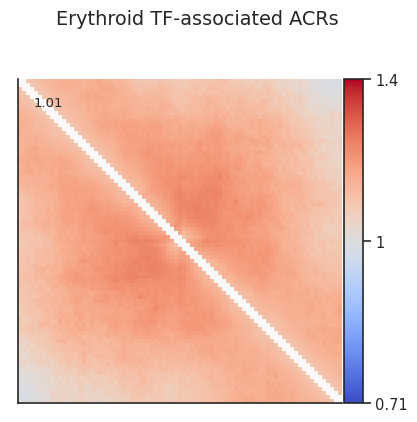

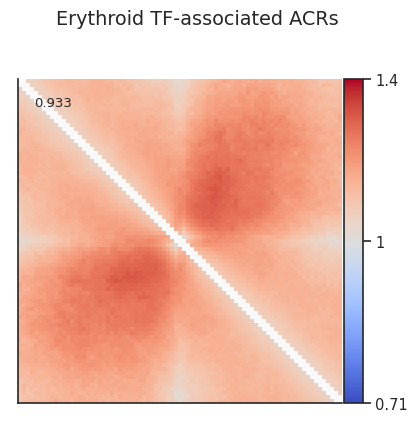

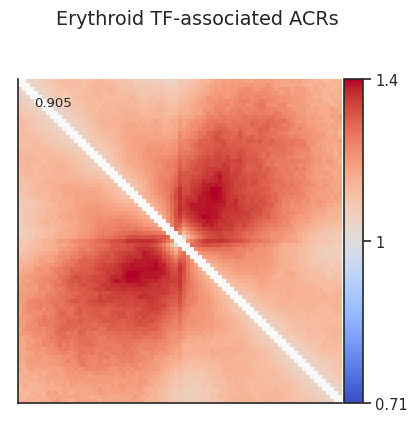

In [47]:
## All erythroid TF CREs
track_dir = "/mnt/md0/varshini/Analysis/Blood/complete_analyses/track_defs/erythroid_tracks/classifications"
eryTF = pd.read_csv(os.path.join(track_dir, "erythroid_tf_acrs_all_enhancernotpromoternotctcf.bed"),sep="\t",
                   names=['chr','start','end','score','perturbation_name'])
eryTF_unique = eryTF.drop_duplicates(['chr','start','end']).rename({'chr':'chrom'},axis=1)

for p in [0, 1, 2]:
    clr = phase_clrs[p]
    exp0 =  pd.read_csv(exps[p], sep='\t')
    pup_control_incl = coolpup.pileup(clr, eryTF_unique[['chrom','start','end']], features_format='bed', local=True, view_df=hg38_arms,
                                flank=200_000, expected_df = exp0, min_diag=0, nproc=8, subset=5000, )
    fg = plotpup.plot(pup_control_incl,
                     score=True, cmap='coolwarm', scale='log', sym=True,
                     height=5, vmax=VMAX_GLOBAL)
    fg.fig.suptitle("Erythroid TF-associated ACRs")
    fg.savefig(os.path.join(datapath, outdir, f"eryTF_CRE_{p+1}.svg"))


      chrom      start        end
0      chr2  217827363  217828286
1      chr5  173860317  173861249
2      chr5  154653636  154654552
3     chr17   65173211   65174080
4     chr19   18156817   18157733
...     ...        ...        ...
2972  chr11   69073126   69074050
2973   chr1   35505785   35507023
2974   chr5  177427771  177428668
2975  chr17   68446338   68447323
2976   chr6   42028189   42029129

[2977 rows x 3 columns]
erythroid_tf_acrs_all_enhancernotpromoternotctcf: GATA1


INFO:coolpuppy:('chr5_p', 'chr5_p'): 27
INFO:coolpuppy:('chr4_p', 'chr4_p'): 26
INFO:coolpuppy:('chr8_p', 'chr8_p'): 46
INFO:coolpuppy:('chr7_p', 'chr7_p'): 69
INFO:coolpuppy:('chr6_p', 'chr6_p'): 116
INFO:coolpuppy:('chr3_p', 'chr3_p'): 102
INFO:coolpuppy:('chr2_p', 'chr2_p'): 95
INFO:coolpuppy:('chr8_q', 'chr8_q'): 83
INFO:coolpuppy:('chr7_q', 'chr7_q'): 77
INFO:coolpuppy:('chr1_p', 'chr1_p'): 170
INFO:coolpuppy:('chr9_p', 'chr9_p'): 32
INFO:coolpuppy:('chr6_q', 'chr6_q'): 73
INFO:coolpuppy:('chr5_q', 'chr5_q'): 135
INFO:coolpuppy:('chr10_p', 'chr10_p'): 32
INFO:coolpuppy:('chr4_q', 'chr4_q'): 83
INFO:coolpuppy:('chr12_p', 'chr12_p'): 31
INFO:coolpuppy:('chr3_q', 'chr3_q'): 103
INFO:coolpuppy:('chr11_p', 'chr11_p'): 75
INFO:coolpuppy:('chr9_q', 'chr9_q'): 105
INFO:coolpuppy:('chr13_q', 'chr13_q'): 55
INFO:coolpuppy:('chr10_q', 'chr10_q'): 82
INFO:coolpuppy:('chr12_q', 'chr12_q'): 101
INFO:coolpuppy:('chr17_p', 'chr17_p'): 27
INFO:coolpuppy:('chr16_p', 'chr16_p'): 43
INFO:coolpuppy:('

     chrom      start        end
0    chr22   40955353   40956297
1     chr8  100410259  100411123
2    chr19    3502724    3503670
3    chr17   21294348   21295193
4     chr8    1759840    1760759
..     ...        ...        ...
526   chr5  133932464  133933402
527   chr7   12731242   12732237
528   chr7  135663738  135664681
529  chr15   75946882   75947829
530  chr17   81885903   81886825

[531 rows x 3 columns]
erythroid_tf_acrs_all_enhancernotpromoternotctcf: LMO2


INFO:coolpuppy:('chr5_p', 'chr5_p'): 1
INFO:coolpuppy:('chr4_p', 'chr4_p'): 4
INFO:coolpuppy:('chr8_p', 'chr8_p'): 11
INFO:coolpuppy:('chr7_p', 'chr7_p'): 17
INFO:coolpuppy:('chr6_p', 'chr6_p'): 20
INFO:coolpuppy:('chr2_p', 'chr2_p'): 14
INFO:coolpuppy:('chr3_p', 'chr3_p'): 17
INFO:coolpuppy:('chr8_q', 'chr8_q'): 19
INFO:coolpuppy:('chr1_p', 'chr1_p'): 30
INFO:coolpuppy:('chr7_q', 'chr7_q'): 14
INFO:coolpuppy:('chr9_p', 'chr9_p'): 7
INFO:coolpuppy:('chr6_q', 'chr6_q'): 8
INFO:coolpuppy:('chr4_q', 'chr4_q'): 10
INFO:coolpuppy:('chr10_p', 'chr10_p'): 6
INFO:coolpuppy:('chr5_q', 'chr5_q'): 30
INFO:coolpuppy:('chr12_p', 'chr12_p'): 4
INFO:coolpuppy:('chr11_p', 'chr11_p'): 13
INFO:coolpuppy:('chr3_q', 'chr3_q'): 18
INFO:coolpuppy:('chr9_q', 'chr9_q'): 18
INFO:coolpuppy:('chr13_q', 'chr13_q'): 8
INFO:coolpuppy:('chr10_q', 'chr10_q'): 8
INFO:coolpuppy:('chr2_q', 'chr2_q'): 22
INFO:coolpuppy:('chr16_p', 'chr16_p'): 10
INFO:coolpuppy:('chr1_q', 'chr1_q'): 26
INFO:coolpuppy:('chr17_p', 'chr17_p'

      chrom      start        end
0      chr2  217827363  217828286
1      chr5  173860317  173861249
2      chr5  154653636  154654552
3     chr17   65173211   65174080
4     chr19   18156817   18157733
...     ...        ...        ...
2972  chr11   69073126   69074050
2973   chr1   35505785   35507023
2974   chr5  177427771  177428668
2975  chr17   68446338   68447323
2976   chr6   42028189   42029129

[2977 rows x 3 columns]
erythroid_tf_acrs_all_enhancernotpromoternotctcf: GATA1


...

INFO:coolpuppy:('chr5_p', 'chr5_p'): 1
INFO:coolpuppy:('chr4_p', 'chr4_p'): 4
INFO:coolpuppy:('chr8_p', 'chr8_p'): 11
INFO:coolpuppy:('chr7_p', 'chr7_p'): 17
INFO:coolpuppy:('chr6_p', 'chr6_p'): 20
INFO:coolpuppy:('chr3_p', 'chr3_p'): 17
INFO:coolpuppy:('chr2_p', 'chr2_p'): 14
INFO:coolpuppy:('chr7_q', 'chr7_q'): 14
INFO:coolpuppy:('chr1_p', 'chr1_p'): 30
INFO:coolpuppy:('chr8_q', 'chr8_q'): 19
INFO:coolpuppy:('chr9_p', 'chr9_p'): 7
INFO:coolpuppy:('chr6_q', 'chr6_q'): 8
INFO:coolpuppy:('chr4_q', 'chr4_q'): 10
INFO:coolpuppy:('chr5_q', 'chr5_q'): 30
INFO:coolpuppy:('chr10_p', 'chr10_p'): 6
INFO:coolpuppy:('chr3_q', 'chr3_q'): 18
INFO:coolpuppy:('chr12_p', 'chr12_p'): 4
INFO:coolpuppy:('chr11_p', 'chr11_p'): 13
INFO:coolpuppy:('chr9_q', 'chr9_q'): 18
INFO:coolpuppy:('chr2_q', 'chr2_q'): 22
INFO:coolpuppy:('chr13_q', 'chr13_q'): 8
INFO:coolpuppy:('chr14_q', 'chr14_q'): 18
INFO:coolpuppy:('chr1_q', 'chr1_q'): 26
INFO:coolpuppy:('chr18_p', 'chr18_p'): 6
INFO:coolpuppy:('chr10_q', 'chr10_q'

      chrom      start        end
0      chr2  217827363  217828286
1      chr5  173860317  173861249
2      chr5  154653636  154654552
3     chr17   65173211   65174080
4     chr19   18156817   18157733
...     ...        ...        ...
2972  chr11   69073126   69074050
2973   chr1   35505785   35507023
2974   chr5  177427771  177428668
2975  chr17   68446338   68447323
2976   chr6   42028189   42029129

[2977 rows x 3 columns]
erythroid_tf_acrs_all_enhancernotpromoternotctcf: GATA1


INFO:coolpuppy:('chr5_p', 'chr5_p'): 27
INFO:coolpuppy:('chr4_p', 'chr4_p'): 26
INFO:coolpuppy:('chr8_p', 'chr8_p'): 46
INFO:coolpuppy:('chr6_p', 'chr6_p'): 116
INFO:coolpuppy:('chr7_p', 'chr7_p'): 69
INFO:coolpuppy:('chr3_p', 'chr3_p'): 102
INFO:coolpuppy:('chr2_p', 'chr2_p'): 95
INFO:coolpuppy:('chr8_q', 'chr8_q'): 83
INFO:coolpuppy:('chr1_p', 'chr1_p'): 170
INFO:coolpuppy:('chr7_q', 'chr7_q'): 77
INFO:coolpuppy:('chr6_q', 'chr6_q'): 73
INFO:coolpuppy:('chr9_p', 'chr9_p'): 32
INFO:coolpuppy:('chr5_q', 'chr5_q'): 135
INFO:coolpuppy:('chr10_p', 'chr10_p'): 32
INFO:coolpuppy:('chr4_q', 'chr4_q'): 83
INFO:coolpuppy:('chr12_p', 'chr12_p'): 31
INFO:coolpuppy:('chr11_p', 'chr11_p'): 75
INFO:coolpuppy:('chr3_q', 'chr3_q'): 103
INFO:coolpuppy:('chr9_q', 'chr9_q'): 105
INFO:coolpuppy:('chr1_q', 'chr1_q'): 157
INFO:coolpuppy:('chr13_q', 'chr13_q'): 55
INFO:coolpuppy:('chr16_p', 'chr16_p'): 43
INFO:coolpuppy:('chr11_q', 'chr11_q'): 97
INFO:coolpuppy:('chr2_q', 'chr2_q'): 117
INFO:coolpuppy:('chr

     chrom      start        end
0    chr22   40955353   40956297
1     chr8  100410259  100411123
2    chr19    3502724    3503670
3    chr17   21294348   21295193
4     chr8    1759840    1760759
..     ...        ...        ...
526   chr5  133932464  133933402
527   chr7   12731242   12732237
528   chr7  135663738  135664681
529  chr15   75946882   75947829
530  chr17   81885903   81886825

[531 rows x 3 columns]
erythroid_tf_acrs_all_enhancernotpromoternotctcf: LMO2


INFO:coolpuppy:('chr5_p', 'chr5_p'): 1
INFO:coolpuppy:('chr4_p', 'chr4_p'): 4
INFO:coolpuppy:('chr8_p', 'chr8_p'): 11
INFO:coolpuppy:('chr6_p', 'chr6_p'): 20
INFO:coolpuppy:('chr7_p', 'chr7_p'): 17
INFO:coolpuppy:('chr3_p', 'chr3_p'): 17
INFO:coolpuppy:('chr2_p', 'chr2_p'): 14
INFO:coolpuppy:('chr8_q', 'chr8_q'): 19
INFO:coolpuppy:('chr1_p', 'chr1_p'): 30
INFO:coolpuppy:('chr7_q', 'chr7_q'): 14
INFO:coolpuppy:('chr6_q', 'chr6_q'): 8
INFO:coolpuppy:('chr9_p', 'chr9_p'): 7
INFO:coolpuppy:('chr5_q', 'chr5_q'): 30
INFO:coolpuppy:('chr10_p', 'chr10_p'): 6
INFO:coolpuppy:('chr4_q', 'chr4_q'): 10
INFO:coolpuppy:('chr12_p', 'chr12_p'): 4
INFO:coolpuppy:('chr3_q', 'chr3_q'): 18
INFO:coolpuppy:('chr11_p', 'chr11_p'): 13
INFO:coolpuppy:('chr9_q', 'chr9_q'): 18
INFO:coolpuppy:('chr13_q', 'chr13_q'): 8
INFO:coolpuppy:('chr2_q', 'chr2_q'): 22
INFO:coolpuppy:('chr10_q', 'chr10_q'): 8
INFO:coolpuppy:('chr1_q', 'chr1_q'): 26
INFO:coolpuppy:('chr14_q', 'chr14_q'): 18
INFO:coolpuppy:('chr18_p', 'chr18_p'

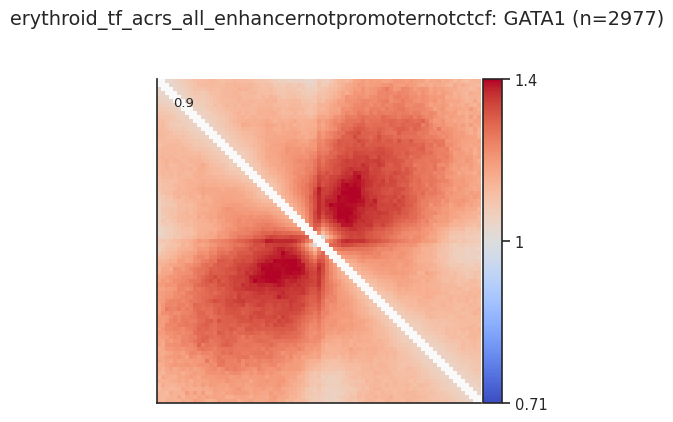

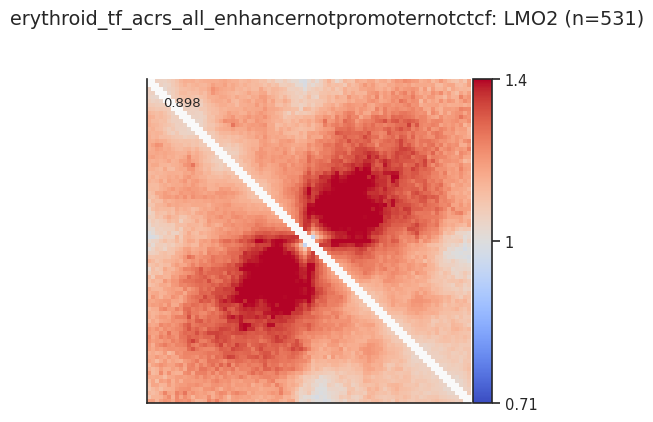

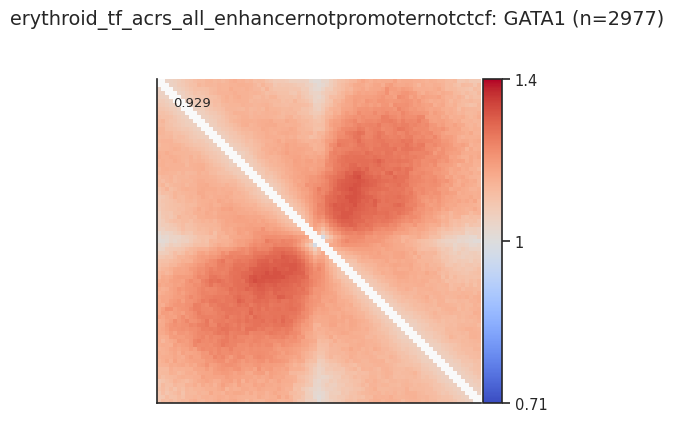

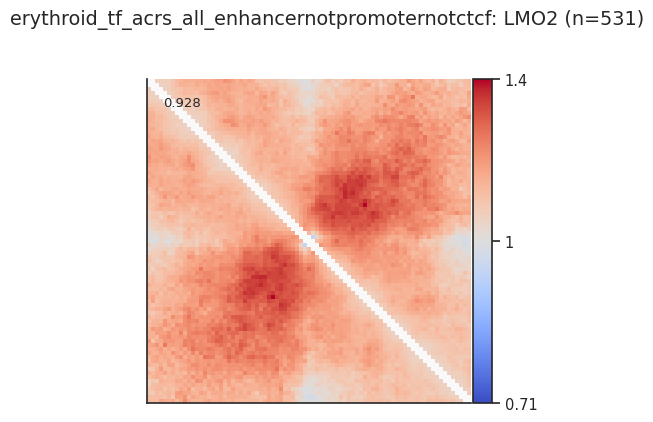

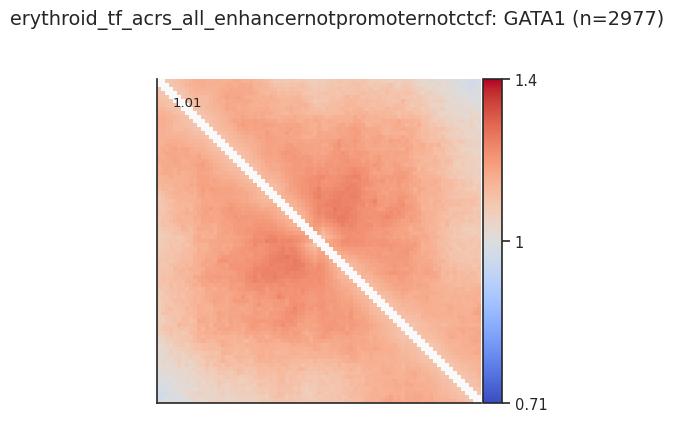

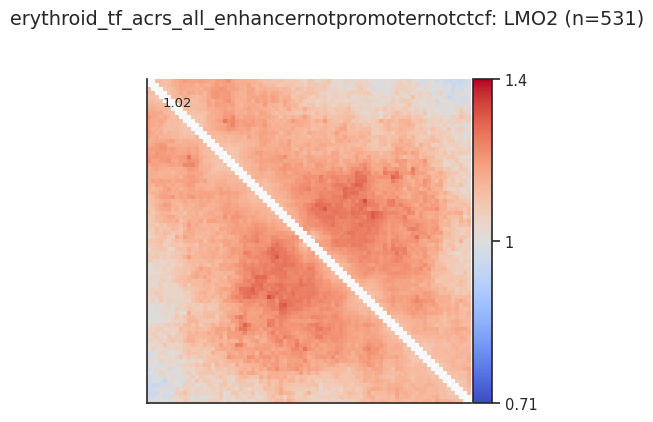

In [40]:
tfs_to_plot = ['GATA1', 'LMO2']

for p in [2, 1, 0]:
    clr = phase_clrs[p]
    exp0 =  pd.read_csv(exps[p], sep='\t')
    for b in bedfiles.keys():
        if ('erythroid_tf_acrs' in b) & ('enhancernotpromoternotctcf' in b):
            di = bedfiles[b]
            for d in di.keys():
                if d in tfs_to_plot:
                    curr_bed = di[d]
                    print(curr_bed)
                    print(f"{b}: {d}")

                    if len(curr_bed) > 5000:
                        subset=5000
                    else:
                        subset=0

                    currpup = coolpup.pileup(clr, curr_bed, features_format='bed', local=True, view_df=hg38_arms,
                                        flank=200_000, expected_df = exp0, min_diag=0, nproc=8, subset=subset)

                    fg = plotpup.plot(currpup,
                             score=True, cmap='coolwarm', scale='log', sym=True,
                             height=5, vmax=VMAX_GLOBAL)

                    fg.fig.suptitle(f"{b}: {d} (n={len(curr_bed)})")
                    fg.savefig(os.path.join(outdir, f"{b}{d}_phase{p+1}.svg"))

In [8]:
track_dir = "/mnt/md0/varshini/Analysis/Blood/complete_analyses/track_defs/erythroid_tracks"

In [9]:
os.listdir("/mnt/md0/varshini/Analysis/Blood/complete_analyses/track_defs/erythroid_tracks/")

['032524_combined_DAP_JAN_028_ATAC.bed',
 'classifications_uniqueE',
 'erythroid_associated_ACRs.bed',
 'erythroid_tf_acrs_all.bed',
 'acrs_unique.bed',
 'ATAC_not_CTCF.bed',
 'erythroid_tf_acrs_unique.bed',
 'tf_acrs_sorted.bed',
 'classifications']

      chr1    1116091    1116109
0     chr1    1290331    1290349
1     chr1    1292018    1292036
2     chr1    1919080    1919098
3     chr1    2546727    2546745
4     chr1    2548186    2548204
...    ...        ...        ...
5072  chrX   49761667   49761685
5073  chrX   55718161   55718179
5074  chrX   65528895   65528913
5075  chrX  132092627  132092645
5076  chrX  149471057  149471075

[5077 rows x 3 columns]


INFO:coolpuppy:('chr5_p', 'chr5_p'): 34
INFO:coolpuppy:('chr4_p', 'chr4_p'): 57
INFO:coolpuppy:('chr8_p', 'chr8_p'): 60
INFO:coolpuppy:('chr7_p', 'chr7_p'): 94
INFO:coolpuppy:('chr6_p', 'chr6_p'): 145
INFO:coolpuppy:('chr3_p', 'chr3_p'): 140
INFO:coolpuppy:('chr2_p', 'chr2_p'): 153
INFO:coolpuppy:('chr8_q', 'chr8_q'): 145
INFO:coolpuppy:('chr7_q', 'chr7_q'): 155
INFO:coolpuppy:('chr1_p', 'chr1_p'): 304
INFO:coolpuppy:('chr9_p', 'chr9_p'): 48
INFO:coolpuppy:('chr6_q', 'chr6_q'): 142
INFO:coolpuppy:('chr5_q', 'chr5_q'): 217
INFO:coolpuppy:('chr10_p', 'chr10_p'): 57
INFO:coolpuppy:('chr4_q', 'chr4_q'): 173
INFO:coolpuppy:('chr12_p', 'chr12_p'): 57
INFO:coolpuppy:('chr3_q', 'chr3_q'): 212
INFO:coolpuppy:('chr11_p', 'chr11_p'): 96
INFO:coolpuppy:('chr9_q', 'chr9_q'): 165
INFO:coolpuppy:('chr10_q', 'chr10_q'): 179
INFO:coolpuppy:('chr13_q', 'chr13_q'): 113
INFO:coolpuppy:('chr2_q', 'chr2_q'): 228
INFO:coolpuppy:('chr16_p', 'chr16_p'): 82
INFO:coolpuppy:('chr17_p', 'chr17_p'): 61
INFO:coolpup

      chr1    1116091    1116109
0     chr1    1290331    1290349
1     chr1    1292018    1292036
2     chr1    1919080    1919098
3     chr1    2546727    2546745
4     chr1    2548186    2548204
...    ...        ...        ...
5072  chrX   49761667   49761685
5073  chrX   55718161   55718179
5074  chrX   65528895   65528913
5075  chrX  132092627  132092645
5076  chrX  149471057  149471075

[5077 rows x 3 columns]


INFO:coolpuppy:('chr8_p', 'chr8_p'): 59
INFO:coolpuppy:('chr4_p', 'chr4_p'): 57
INFO:coolpuppy:('chr7_p', 'chr7_p'): 93
INFO:coolpuppy:('chr5_p', 'chr5_p'): 33
INFO:coolpuppy:('chr6_p', 'chr6_p'): 147
INFO:coolpuppy:('chr3_p', 'chr3_p'): 147
INFO:coolpuppy:('chr7_q', 'chr7_q'): 157
INFO:coolpuppy:('chr9_p', 'chr9_p'): 49
INFO:coolpuppy:('chr8_q', 'chr8_q'): 145
INFO:coolpuppy:('chr3_q', 'chr3_q'): 205
INFO:coolpuppy:('chr10_p', 'chr10_p'): 57
INFO:coolpuppy:('chr9_q', 'chr9_q'): 164
INFO:coolpuppy:('chr11_p', 'chr11_p'): 96
INFO:coolpuppy:('chr6_q', 'chr6_q'): 143
INFO:coolpuppy:('chr12_p', 'chr12_p'): 58
INFO:coolpuppy:('chr10_q', 'chr10_q'): 175
INFO:coolpuppy:('chr11_q', 'chr11_q'): 153
INFO:coolpuppy:('chr4_q', 'chr4_q'): 171
INFO:coolpuppy:('chr13_q', 'chr13_q'): 112
INFO:coolpuppy:('chr2_p', 'chr2_p'): 153
INFO:coolpuppy:('chr12_q', 'chr12_q'): 186
INFO:coolpuppy:('chr1_p', 'chr1_p'): 306
INFO:coolpuppy:('chr18_p', 'chr18_p'): 25
INFO:coolpuppy:('chr16_p', 'chr16_p'): 80
INFO:coo

      chr1    1116091    1116109
0     chr1    1290331    1290349
1     chr1    1292018    1292036
2     chr1    1919080    1919098
3     chr1    2546727    2546745
4     chr1    2548186    2548204
...    ...        ...        ...
5072  chrX   49761667   49761685
5073  chrX   55718161   55718179
5074  chrX   65528895   65528913
5075  chrX  132092627  132092645
5076  chrX  149471057  149471075

[5077 rows x 3 columns]


INFO:coolpuppy:('chr5_p', 'chr5_p'): 34
INFO:coolpuppy:('chr4_p', 'chr4_p'): 55
INFO:coolpuppy:('chr8_p', 'chr8_p'): 60
INFO:coolpuppy:('chr7_p', 'chr7_p'): 93
INFO:coolpuppy:('chr6_p', 'chr6_p'): 146
INFO:coolpuppy:('chr7_q', 'chr7_q'): 154
INFO:coolpuppy:('chr3_p', 'chr3_p'): 145
INFO:coolpuppy:('chr2_p', 'chr2_p'): 156
INFO:coolpuppy:('chr9_p', 'chr9_p'): 49
INFO:coolpuppy:('chr8_q', 'chr8_q'): 144
INFO:coolpuppy:('chr6_q', 'chr6_q'): 139
INFO:coolpuppy:('chr9_q', 'chr9_q'): 163
INFO:coolpuppy:('chr10_p', 'chr10_p'): 58
INFO:coolpuppy:('chr1_p', 'chr1_p'): 303
INFO:coolpuppy:('chr5_q', 'chr5_q'): 218
INFO:coolpuppy:('chr12_p', 'chr12_p'): 58
INFO:coolpuppy:('chr11_p', 'chr11_p'): 98
INFO:coolpuppy:('chr4_q', 'chr4_q'): 171
INFO:coolpuppy:('chr13_q', 'chr13_q'): 113
INFO:coolpuppy:('chr10_q', 'chr10_q'): 178
INFO:coolpuppy:('chr12_q', 'chr12_q'): 188
INFO:coolpuppy:('chr11_q', 'chr11_q'): 151
INFO:coolpuppy:('chr14_q', 'chr14_q'): 171
INFO:coolpuppy:('chr17_p', 'chr17_p'): 62
INFO:co

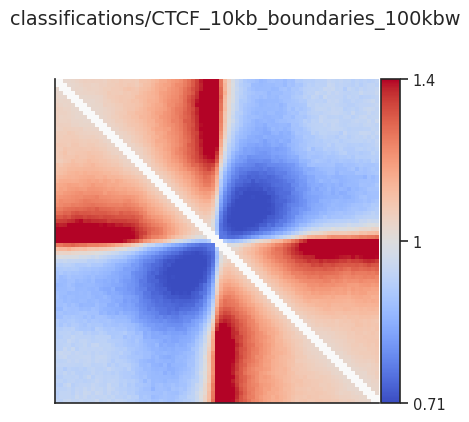

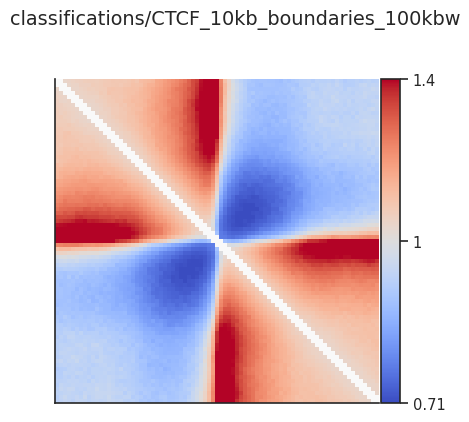

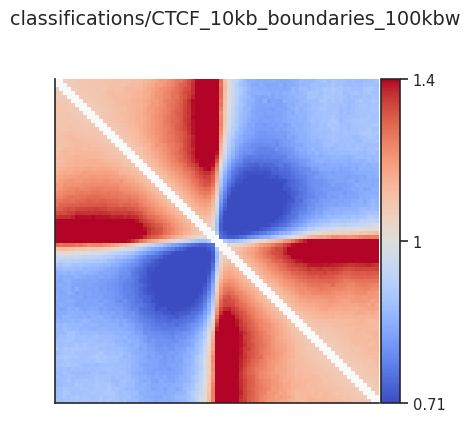

In [25]:
keys = ["ATAC_not_CTCF",
        "classifications/promoternotctcf_accessible", 
        "classifications/CTCF_10kb_boundaries",
        "classifications/CTCF_10kb_boundaries_100kbw"]

keys = ["classifications/CTCF_10kb_boundaries_100kbw"]
for p in [2, 1, 0]:
    clr = phase_clrs[p]
    exp0 =  pd.read_csv(exps[p], sep='\t')

    for key in keys:
        curr_bed =  pd.read_csv(f"{track_dir}/{key}.bed", sep='\t')
        print(curr_bed)
        if len(curr_bed) > 5000:
            subset=5000
        else:
            subset=len(curr_bed)
            
        curr_bed = curr_bed.iloc[:, :3]
        curr_bed.columns = ['chrom','start','end']

        currpup = coolpup.pileup(clr, curr_bed, features_format='bed', local=True, view_df=hg38_arms,
                                            flank=200_000, expected_df = exp0, min_diag=0, nproc=8, subset=subset)

        fg = plotpup.plot(currpup,
                    score=False, cmap='coolwarm', scale='log', sym=True,
                    height=5, vmax=VMAX_GLOBAL)

        fg.fig.suptitle(f"{key}")
        fg.savefig(os.path.join(outdir, f"{key.split('/')[-1]}_phase{p+1}.svg"))